In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [4]:
raw = np.load("/content/PEMS08.npz")
data = raw["data"].astype(np.float32)

data = data[:, :, 0]   # traffic flow channel

SENSORS = data.shape[1]
print("Shape:", data.shape)

Shape: (17856, 170)


In [5]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [6]:
SEQ_LEN = 96
PRED_LEN = 12

def create_sequences(data):
    X, Y = [], []
    for i in range(len(data) - SEQ_LEN - PRED_LEN):
        X.append(data[i:i+SEQ_LEN])
        Y.append(data[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])
    return np.array(X), np.array(Y)

X, Y = create_sequences(data)

In [7]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X).float()
        self.Y = torch.tensor(Y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = TrafficDataset(X, Y)

split = int(0.8 * len(dataset))
train_set = torch.utils.data.Subset(dataset, range(split))
val_set   = torch.utils.data.Subset(dataset, range(split, len(dataset)))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32)

In [8]:
class AdaptiveGraphConv(nn.Module):
    def __init__(self, sensors, in_dim, out_dim, embed_dim=10):
        super().__init__()

        self.nodevec1 = nn.Parameter(torch.randn(sensors, embed_dim))
        self.nodevec2 = nn.Parameter(torch.randn(embed_dim, sensors))

        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        # x: (B, T, N, F)

        A = torch.softmax(
            torch.relu(self.nodevec1 @ self.nodevec2),
            dim=1
        )

        x = torch.einsum("ij,btjf->btif", A, x)

        return self.linear(x)

In [9]:
class Adaptive_GNN_LLM(nn.Module):
    def __init__(self, sensors, pred_len):
        super().__init__()

        hidden = 64
        llm_dim = 128

        self.gcn1 = AdaptiveGraphConv(sensors, 1, hidden)
        self.gcn2 = AdaptiveGraphConv(sensors, hidden, hidden)

        self.temporal = nn.Sequential(
            nn.Conv2d(hidden, hidden, (3,1), padding=(1,0)),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, (3,1), padding=(1,0)),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(
            hidden,
            llm_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=llm_dim,
            nhead=8,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=3
        )

        self.fc = nn.Linear(llm_dim, sensors * pred_len)

        self.pred_len = pred_len
        self.sensors = sensors

    def forward(self, x):

        x = x.unsqueeze(-1)  # (B,T,N,1)

        x = torch.relu(self.gcn1(x))
        x = torch.relu(self.gcn2(x))

        B,T,N,F = x.shape
        x = x.permute(0,3,1,2)

        x = self.temporal(x)

        x = x.permute(0,2,3,1)

        x = x.mean(dim=2)

        x,_ = self.lstm(x)

        x = self.transformer(x)

        x = x[:, -1, :]

        out = self.fc(x)

        return out.view(-1, self.pred_len, self.sensors)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Adaptive_GNN_LLM(SENSORS, PRED_LEN).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=3,
    factor=0.5
)

loss_fn = nn.HuberLoss()

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=3,
    factor=0.5
)

loss_fn = nn.HuberLoss()

best_val = float("inf")
patience = 8
counter = 0

EPOCHS = 60

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            val_loss += loss_fn(pred, y).item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch} | Train {train_loss:.5f} | Val {val_loss:.5f}")

    # ---- EARLY STOP ----
    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch 0 | Train 0.01962 | Val 0.00507
Epoch 1 | Train 0.00467 | Val 0.00424
Epoch 2 | Train 0.00427 | Val 0.00414
Epoch 3 | Train 0.00407 | Val 0.00378
Epoch 4 | Train 0.00384 | Val 0.00396
Epoch 5 | Train 0.00363 | Val 0.00380
Epoch 6 | Train 0.00346 | Val 0.00357
Epoch 7 | Train 0.00332 | Val 0.00327
Epoch 8 | Train 0.00320 | Val 0.00330
Epoch 9 | Train 0.00309 | Val 0.00319
Epoch 10 | Train 0.00299 | Val 0.00302
Epoch 11 | Train 0.00292 | Val 0.00291
Epoch 12 | Train 0.00286 | Val 0.00287
Epoch 13 | Train 0.00279 | Val 0.00301
Epoch 14 | Train 0.00274 | Val 0.00289
Epoch 15 | Train 0.00270 | Val 0.00289
Epoch 16 | Train 0.00262 | Val 0.00285
Epoch 17 | Train 0.00257 | Val 0.00299
Epoch 18 | Train 0.00252 | Val 0.00270
Epoch 19 | Train 0.00247 | Val 0.00278
Epoch 20 | Train 0.00244 | Val 0.00274
Epoch 21 | Train 0.00239 | Val 0.00272
Epoch 22 | Train 0.00235 | Val 0.00282
Epoch 23 | Train 0.00224 | Val 0.00270
Epoch 24 | Train 0.00222 | Val 0.00288
Epoch 25 | Train 0.00219 | Val 0.00

In [13]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

preds = []
actual = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        p = model(x).cpu().numpy()
        preds.append(p)
        actual.append(y.numpy())

preds = np.concatenate(preds)
actual = np.concatenate(actual)

# ---- DENORMALIZE ----
preds_denorm = scaler.inverse_transform(
    preds.reshape(-1, preds.shape[-1])
).reshape(preds.shape)

actual_denorm = scaler.inverse_transform(
    actual.reshape(-1, actual.shape[-1])
).reshape(actual.shape)

# ---- METRICS ----
mae = np.mean(np.abs(preds_denorm - actual_denorm))
rmse = np.sqrt(np.mean((preds_denorm - actual_denorm) ** 2))

mask = actual_denorm > 10
mape = np.mean(
    np.abs((actual_denorm[mask] - preds_denorm[mask]) /
           actual_denorm[mask])
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 21.28552
RMSE: 35.56152
MAPE: 11.843196


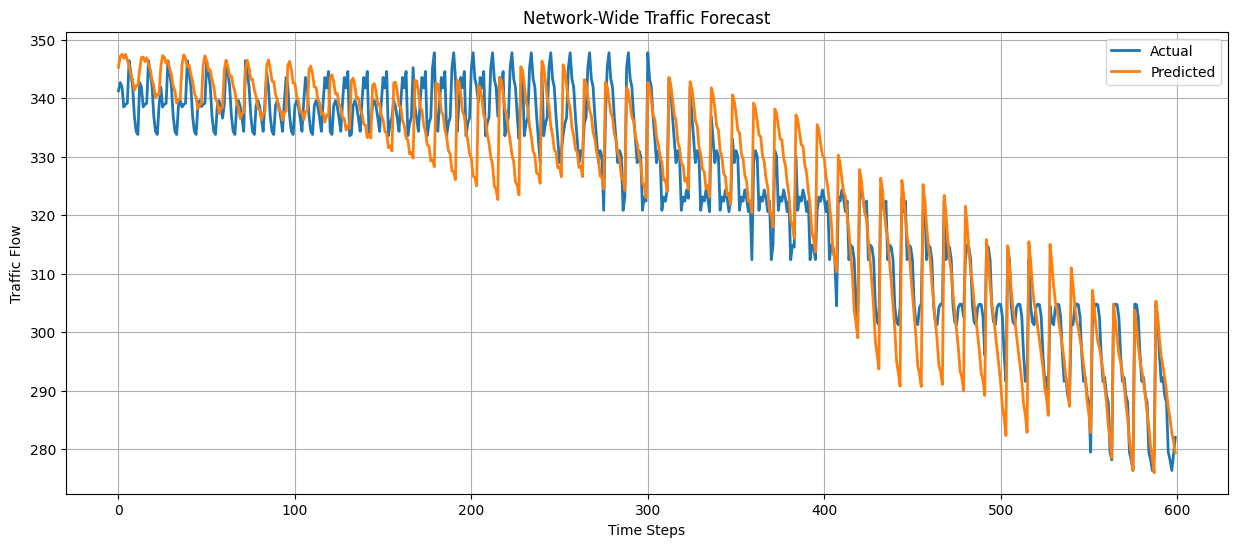

In [14]:
actual_mean = actual_denorm.mean(axis=2)
pred_mean   = preds_denorm.mean(axis=2)

actual_flat = actual_mean.reshape(-1)
pred_flat   = pred_mean.reshape(-1)

plt.figure(figsize=(15,6))
plt.plot(actual_flat[:600], label="Actual", linewidth=2)
plt.plot(pred_flat[:600], label="Predicted", linewidth=2)

plt.title("Network-Wide Traffic Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Traffic Flow")
plt.legend()
plt.grid(True)
plt.show()